# First Dataset

(0.0, 1.0)

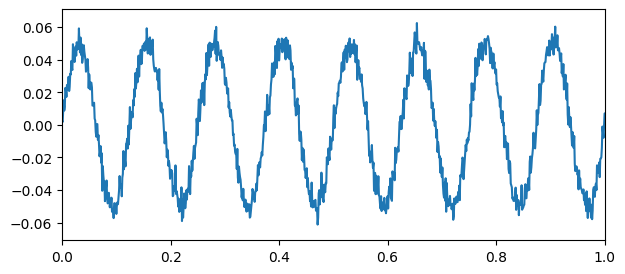

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data1 = np.loadtxt("seismic_test_dataset7.txt", skiprows = 1, delimiter = ',')
t = data1[:,0]
V = data1[:,1]
noise = data1[:,2]

fig = plt.figure(figsize=(7, 3))
ax = fig.add_subplot(1, 1, 1)
ax.plot(t, V)
ax.set_xlim([0,1])

### PSD

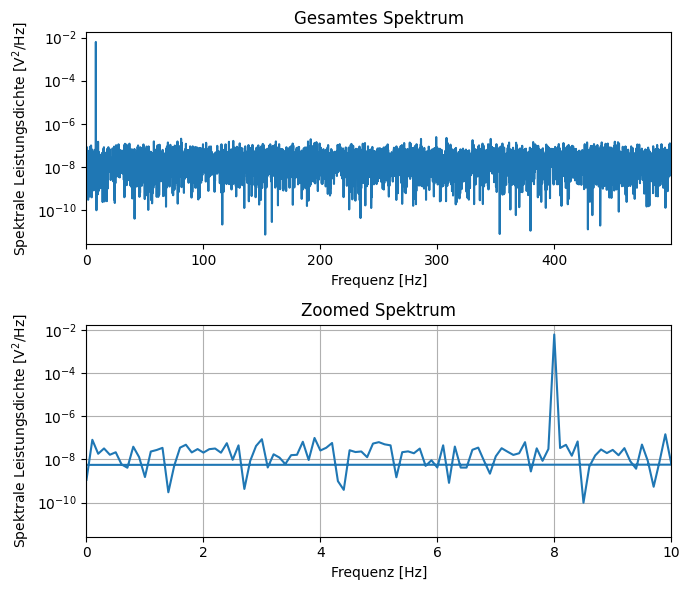

In [2]:
N = len(t)
dt = t[1] - t[0]
# print(dt)

# Berechnen der geordneten Frequenzachse
f = np.fft.fftfreq(N, dt)
# Berechnen der Fouriertransformation
spectrum = np.fft.fft(V)
# Berechnen der spektralen Leistungsdichte
psd = dt / N * np.abs(spectrum)**2

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(2, 1, 1)
ax.plot(f, psd)
ax.set_xlabel('Frequenz [Hz]')
ax.set_ylabel(r'Spektrale Leistungsdichte [V$^2$/Hz]')
ax.set_title('Gesamtes Spektrum')
ax.set_xlim([0,np.max(f)])
plt.yscale('log')

ax = fig.add_subplot(2, 1, 2)
ax.plot(f, psd)
ax.set_xlabel('Frequenz [Hz]')
ax.set_ylabel(r'Spektrale Leistungsdichte [V$^2$/Hz]')
ax.set_title('Zoomed Spektrum')
ax.set_xlim([0, 10])
plt.yscale('log')
ax.grid('true')

fig.tight_layout()

The only visible peak in our PSD plot is around 7 Hz.
Hence, the recording is about a small sismic event.

### Variance

In [3]:
# We first compute the variance of the noise alone.
var_noise = np.var(noise)
print(var_noise)
# We now compute the variance of the whole signal
var_ges = np.var(V)
print(var_ges)
# Thanks to Pascal Thm we can just subctract the two
var_ground = var_ges - var_noise
print(var_ground)

# Let's check for an eyeballed source signal
x = np.arange(0, 100, 0.001)
sin = 0.02 * np.sin(14 * np.pi * x)   # use np.sin, not math.sin
print(np.var(sin))

2.5048033039491148e-05
0.0012724760448166426
0.0012474280117771514
0.00019999999999999993


The variance of the ground vibration alone is 0.00020 V$^2$

### Kovarianz

In [4]:
# I prefer to look at the normalisierte Korrelationkoeffizienten rather than
# at the Kovarianzmatrix.
print(np.cov(V,noise))
print(np.corrcoef(V,noise))

[[ 1.27260331e-03 -2.48349401e-06]
 [-2.48349401e-06  2.50505381e-05]]
[[ 1.         -0.01390939]
 [-0.01390939  1.        ]]


# Second Dataset

In [5]:
data2 = np.loadtxt('earthquake_waiting_times7.txt', skiprows = 1)
data2.shape

(500,)

### Probability

In [6]:
# fig = plt.figure(figsize=(7, 3))
# ax = fig.add_subplot(1,1,1)
# ax.plot(data2)
# plt.yscale('log')

mean = np.mean(data2)
print('Mean waiting time: {}'.format(mean))

import math
# P(T <= 30s) = 1 - exp(-30s/tao)
prob = 1 - math.exp(-30/mean)
print('Probability P(T<=30s): {}'.format(prob))

Mean waiting time: 37.159439627380955
Probability P(T<=30s): 0.553953411171735
